# Task 1 — Data Loading, Merging & Deep Exploration


In [409]:
#import

#data handling
import pandas as pd
import numpy as np

#visualization
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px


In [410]:
import warnings
warnings.filterwarnings("ignore")

plt.style.use("ggplot")

In [411]:
#Load the dataset

sales = pd.read_csv("train.csv")


In [412]:
#display first 5 rows
sales.head()


,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales
0,1,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600
1,2,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400
2,3,CA-2017-138688,12/06/2017,16/06/2017,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036.0,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200
3,4,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775
4,5,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680


In [413]:
sales[["Order Date","Ship Date"]].head(10)

,Order Date,Ship Date
0,08/11/2017,11/11/2017
1,08/11/2017,11/11/2017
2,12/06/2017,16/06/2017
3,11/10/2016,18/10/2016
4,11/10/2016,18/10/2016
5,09/06/2015,14/06/2015
6,09/06/2015,14/06/2015
7,09/06/2015,14/06/2015
8,09/06/2015,14/06/2015
9,09/06/2015,14/06/2015


In [414]:
#Parse the Order Date and Ship Date columns as proper datetime objects
sales["Order Date"] = pd.to_datetime(sales["Order Date"], dayfirst=True)
sales["Ship Date"] = pd.to_datetime(sales["Ship Date"], dayfirst=True)

In [415]:
sales[["Order Date","Ship Date"]].head()

,Order Date,Ship Date
0,2017-11-08,2017-11-11
1,2017-11-08,2017-11-11
2,2017-06-12,2017-06-16
3,2016-10-11,2016-10-18
4,2016-10-11,2016-10-18


In [416]:
sales.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9800 entries, 0 to 9799
Data columns (total 18 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   Row ID         9800 non-null   int64         
 1   Order ID       9800 non-null   object        
 2   Order Date     9800 non-null   datetime64[ns]
 3   Ship Date      9800 non-null   datetime64[ns]
 4   Ship Mode      9800 non-null   object        
 5   Customer ID    9800 non-null   object        
 6   Customer Name  9800 non-null   object        
 7   Segment        9800 non-null   object        
 8   Country        9800 non-null   object        
 9   City           9800 non-null   object        
 10  State          9800 non-null   object        
 11  Postal Code    9789 non-null   float64       
 12  Region         9800 non-null   object        
 13  Product ID     9800 non-null   object        
 14  Category       9800 non-null   object        
 15  Sub-Category   9800 n

In [417]:
print(sales[["Order Date", "Ship Date"]].dtypes)

Order Date    datetime64[ns]
Ship Date     datetime64[ns]
dtype: object


In [418]:
#Extract time features
# Year
sales["Year"] = sales["Order Date"].dt.year

# Month
sales["Month"] = sales["Order Date"].dt.month

# Week Number
sales["Week Number"] = sales["Order Date"].dt.isocalendar().week

# Day of Week
sales["Day of Week"] = sales["Order Date"].dt.day_name()

# Quarter
sales["Quarter"] = sales["Order Date"].dt.quarter

# Season
sales["Season"] = sales["Month"].replace({
    12:"Winter", 1:"Winter", 2:"Winter",
    3:"Spring", 4:"Spring", 5:"Spring",
    6:"Summer", 7:"Summer", 8:"Summer",
    9:"Autumn", 10:"Autumn", 11:"Autumn"
})

In [419]:
sales.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Category,Sub-Category,Product Name,Sales,Year,Month,Week Number,Day of Week,Quarter,Season
0,1,CA-2017-152156,2017-11-08,2017-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2017,11,45,Wednesday,4,Autumn
1,2,CA-2017-152156,2017-11-08,2017-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,2017,11,45,Wednesday,4,Autumn
2,3,CA-2017-138688,2017-06-12,2017-06-16,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2017,6,24,Monday,2,Summer
3,4,US-2016-108966,2016-10-11,2016-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,2016,10,41,Tuesday,4,Autumn
4,5,US-2016-108966,2016-10-11,2016-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2016,10,41,Tuesday,4,Autumn


In [420]:
sales[["Order Date","Year","Month","Week Number","Day of Week","Quarter","Season"]].head()

,Order Date,Year,Month,Week Number,Day of Week,Quarter,Season
0,2017-11-08,2017,11,45,Wednesday,4,Autumn
1,2017-11-08,2017,11,45,Wednesday,4,Autumn
2,2017-06-12,2017,6,24,Monday,2,Summer
3,2016-10-11,2016,10,41,Tuesday,4,Autumn
4,2016-10-11,2016,10,41,Tuesday,4,Autumn


In [421]:
#check missing values
sales.isnull().sum()

,0
Row ID,0
Order ID,0
Order Date,0
Ship Date,0
Ship Mode,0
Customer ID,0
Customer Name,0
Segment,0
Country,0
City,0


In [422]:
#check duplicate values
sales.duplicated().sum()

np.int64(0)

In [423]:
sales = sales.drop_duplicates()  #drop missing values

In [424]:
#check data types
sales.dtypes

,0
Row ID,int64
Order ID,object
Order Date,datetime64[ns]
Ship Date,datetime64[ns]
Ship Mode,object
Customer ID,object
Customer Name,object
Segment,object
Country,object
City,object


In [425]:
#aggregate daily sales into Weekly sales
weekly_sales = sales.groupby(pd.Grouper(key="Order Date", freq="W"))["Sales"].sum().reset_index()
weekly_sales.head()

,Order Date,Sales
0,2015-01-04,304.508
1,2015-01-11,4619.108
2,2015-01-18,4130.533
3,2015-01-25,3092.544
4,2015-02-01,2527.914


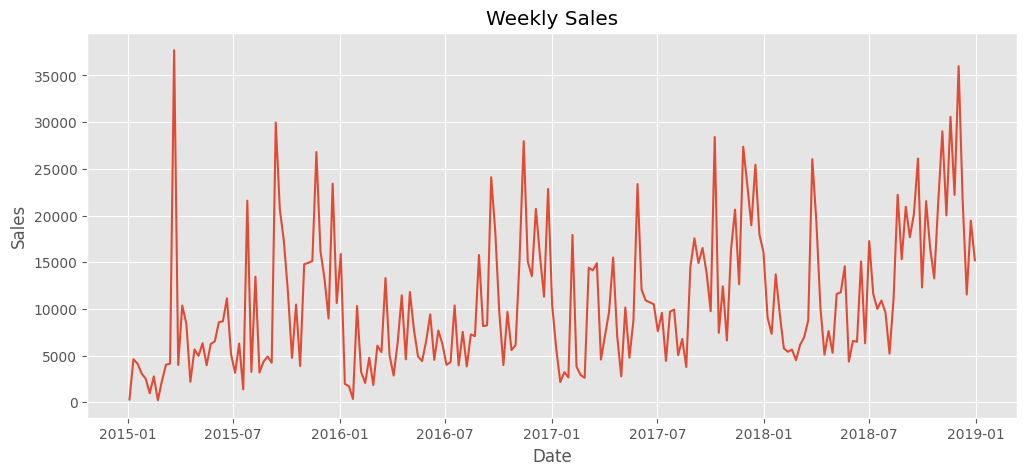

In [426]:
#plot
plt.figure(figsize=(12,5))
plt.plot(weekly_sales["Order Date"], weekly_sales["Sales"])
plt.title("Weekly Sales")
plt.xlabel("Date")
plt.ylabel("Sales")
plt.savefig(
    "weekly_sales.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

In [427]:
#aggregate daily sales into Monthly sales
monthly_sales = sales.groupby(pd.Grouper(key="Order Date", freq="M"))["Sales"].sum().reset_index()
monthly_sales.head()

,Order Date,Sales
0,2015-01-31,14205.707
1,2015-02-28,4519.892
2,2015-03-31,55205.797
3,2015-04-30,27906.855
4,2015-05-31,23644.303


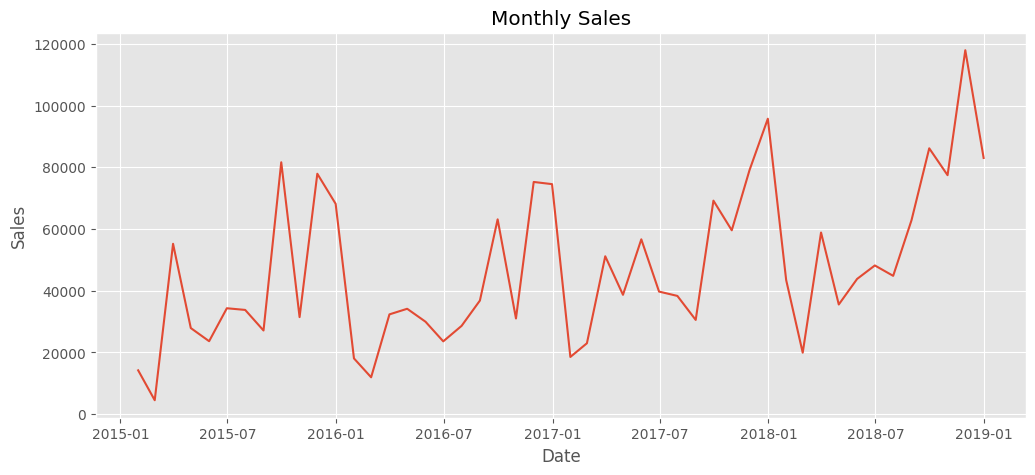

In [428]:
#plot
plt.figure(figsize=(12,5))
plt.plot(monthly_sales["Order Date"], monthly_sales["Sales"])
plt.title("Monthly Sales")
plt.xlabel("Date")
plt.ylabel("Sales")
plt.savefig(
    "monthly_sales.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

Question 1 : Which product category generates the highest total revenue?


Category
Furniture          728658.5757
Office Supplies    705422.3340
Technology         827455.8730
Name: Sales, dtype: float64


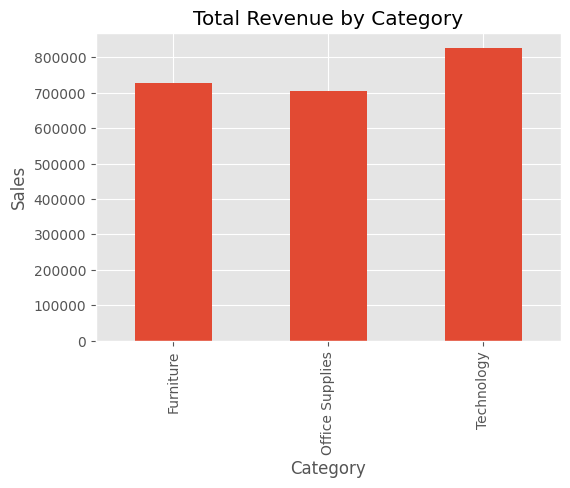

In [429]:
category_sales = sales.groupby("Category")["Sales"].sum()

print(category_sales)

category_sales.plot(kind="bar", figsize=(6,4))
plt.title("Total Revenue by Category")
plt.ylabel("Sales")
plt.savefig(
    "total_revenue_by_category.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

Observation :
Technology generates the highest total revenue

Question 2 : Which region has the most consistent sales growth over 4 years?


In [430]:
region_sales = sales.groupby(["Year","Region"])["Sales"].sum().reset_index()
print(region_sales)

    Year   Region        Sales
0   2015  Central  102920.5206
1   2015     East  127652.8190
2   2015    South  103374.9055
3   2015     West  145907.9630
4   2016  Central  102425.1724
5   2016     East  153225.1830
6   2016    South   70076.0825
7   2016     West  133709.5675
8   2017  Central  145673.8800
9   2017     East  178511.5380
10  2017    South   93535.9035
11  2017     West  182471.2285
12  2018  Central  141627.3402
13  2018     East  210129.1860
14  2018    South  122164.5675
15  2018     West  248130.9255


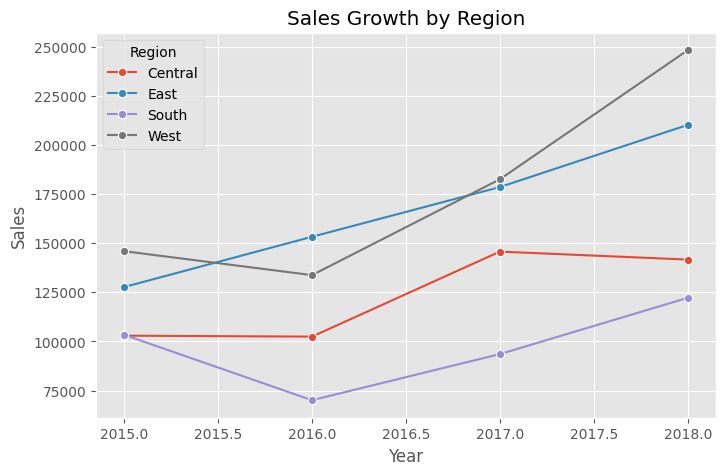

In [431]:
#plot
plt.figure(figsize=(8,5))

sns.lineplot(data=region_sales, x="Year", y="Sales", hue="Region", marker="o")

plt.title("Sales Growth by Region")
plt.savefig(
    "sales_growth_by_region.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

Observation:
The region whose line increases most steadily (least fluctuation) is the most consistent.
West region shows the most consistent growth.

Question 3 : What is the average time between Order Date and Ship Date — and does it vary by region?


In [432]:
sales[["Order Date", "Ship Date"]].head(10)

,Order Date,Ship Date
0,2017-11-08,2017-11-11
1,2017-11-08,2017-11-11
2,2017-06-12,2017-06-16
3,2016-10-11,2016-10-18
4,2016-10-11,2016-10-18
5,2015-06-09,2015-06-14
6,2015-06-09,2015-06-14
7,2015-06-09,2015-06-14
8,2015-06-09,2015-06-14
9,2015-06-09,2015-06-14


In [433]:
sales["Order Date"] = pd.to_datetime(sales["Order Date"], dayfirst=True)
sales["Ship Date"] = pd.to_datetime(sales["Ship Date"], dayfirst=True)

In [434]:
sales["Shipping Days"] = (sales["Ship Date"] - sales["Order Date"]).dt.days

print("Average Shipping Time:", sales["Shipping Days"].mean())

Average Shipping Time: 3.9611224489795918


In [435]:
#Region wise
shipping = sales.groupby("Region")["Shipping Days"].mean()

print(shipping)

Region
Central    4.065876
East       3.910233
South      3.961202
West       3.930255
Name: Shipping Days, dtype: float64


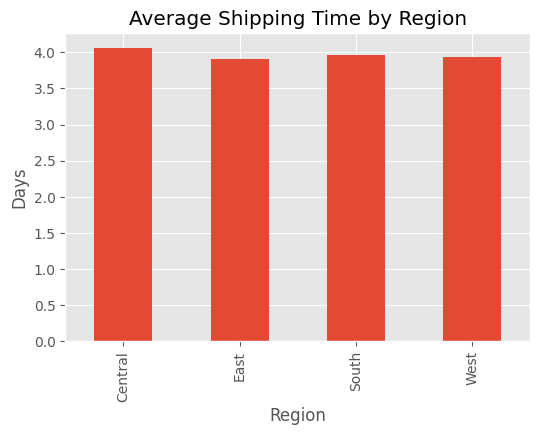

In [436]:
#plot on bar graph

shipping.plot(kind="bar", figsize=(6,4))
plt.title("Average Shipping Time by Region")
plt.ylabel("Days")
plt.savefig(
    "average_shipping_time_by_region.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

Average Shipping Time is about 4 days the shipping duration is very similar across all regions, ranging from about 3.9 to 4.1 days. The Central region has the highest average shipping time, while the East region has the lowest. Overall, the small differences indicate a consistent and efficient delivery process across all regions.

Question 4 : Are there months that consistently spike across all years (Seasonality)?

In [437]:
monthly_sales = sales.groupby(["Year","Month"])["Sales"].sum().reset_index()

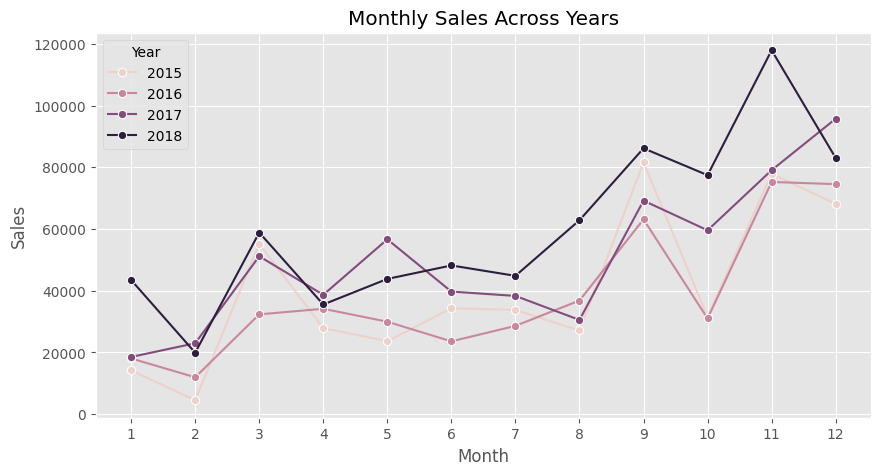

In [438]:
#plot
plt.figure(figsize=(10,5))

sns.lineplot(data=monthly_sales, x="Month", y="Sales", hue="Year", marker="o")

plt.title("Monthly Sales Across Years")
plt.xticks(range(1,13))
plt.savefig(
    "monthly_sales_across_years.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

Observation:
The months that show repeated peaks (like 8, etc) across different years indicate seasonality. November records the highest sales across most years, indicating strong seasonal demand driven by holiday shopping, festive sales, and year-end promotions.

# Task 2 — Time Series Analysis & Decomposition

In [439]:
# Time Series
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.statespace.sarimax import SARIMAX


In [440]:
monthly_sales = sales.groupby(pd.Grouper(key="Order Date", freq="M"))["Sales"].sum()

In [441]:
monthly_sales.head()

,Sales
Order Date,
2015-01-31,14205.707
2015-02-28,4519.892
2015-03-31,55205.797
2015-04-30,27906.855
2015-05-31,23644.303


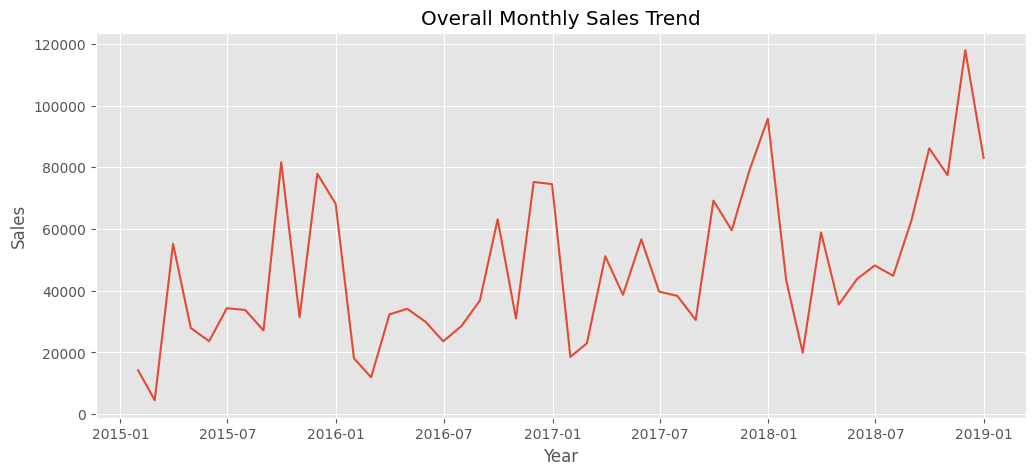

In [442]:
#plot monthly sales
plt.figure(figsize=(12,5))
plt.plot(monthly_sales)
plt.title("Overall Monthly Sales Trend")
plt.xlabel("Year")
plt.ylabel("Sales")
plt.savefig(
    "monthly_sales_by_trend.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

In [443]:
#TIME SERIES DECOMPOSITION
decomposition = seasonal_decompose(
    monthly_sales,
    model="additive",
    period=12
)

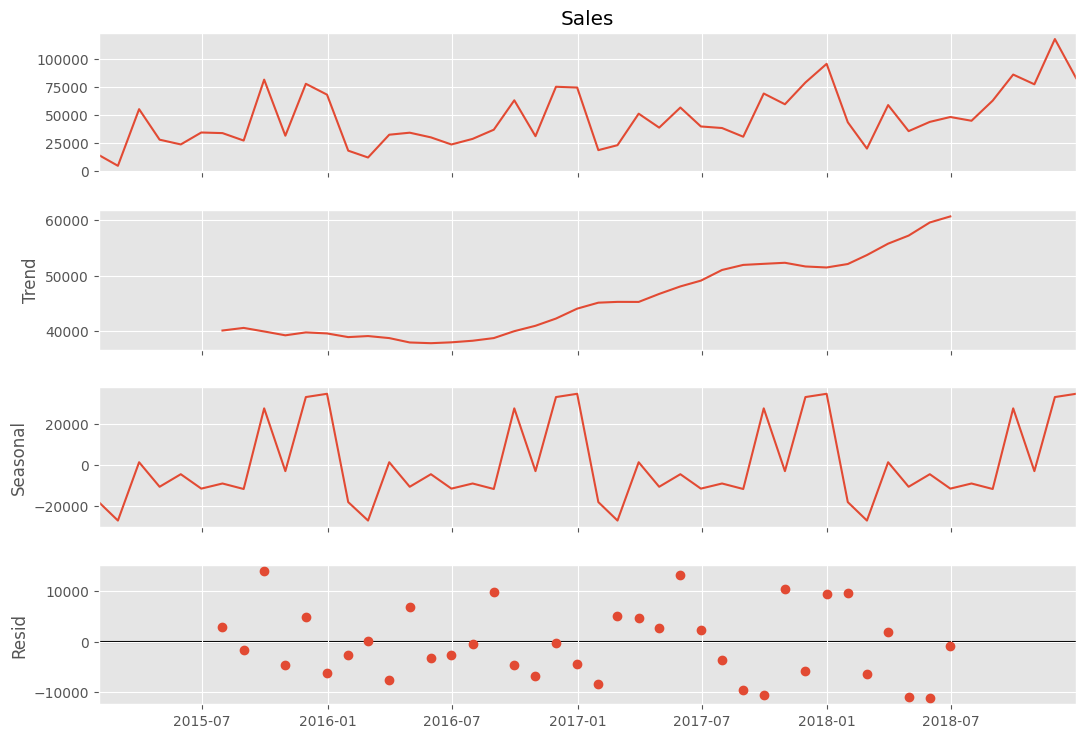

In [444]:
#plot the graph
fig = decomposition.plot()
fig.set_size_inches(12,8)
plt.savefig(
    "time_series_decomposition.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

Observation :

Trend Component :
The trend component shows an overall upward movement in sales over the four-year period. This indicates steady business growth over time.


Seasonality Component :
The seasonal component shows a clear and repeating yearly pattern. the seasonality in the sales data is strong.

Residual (Noise) Component :
The residual component fluctuates around zero, indicating random variations that are not explained by the trend or seasonal patterns.

Overall Interpretation :
The decomposition indicates that monthly sales are influenced by both a long-term upward trend and strong seasonal effects, while the remaining residual variations are comparatively small and represent irregular fluctuations.


What does the trend tell you?
- The trend shows a gradual upward increase in sales over the four-year period. After a slight decline in the early months, sales steadily grow from 2016 onwards, indicating consistent business growth and increasing customer demand.

Is seasonality strong or weak?
- The seasonality is strong. A similar pattern of peaks and dips repeats every year, indicating that sales are influenced by recurring seasonal events.

What months show the highest residual noise?
- The highest residual noise is observed mainly during mid-2017 and early-2018.

In [445]:
#ADF TEST
result = adfuller(monthly_sales)

print("ADF Statistic:", result[0])
print("p-value:", result[1])

ADF Statistic: -4.416136761430769
p-value: 0.00027791039276670623


Stationarity means that the statistical properties of a time series, such as its mean and variance, remain relatively constant over time. Stationary data is important because forecasting models like SARIMA perform better when the data does not have changing trends or unpredictable variations.

The Augmented Dickey-Fuller (ADF) test produced an ADF statistic of -4.4161 with a p-value of 0.000278. Since the p-value is less than 0.05, we reject the null hypothesis of a unit root.

In [446]:
#print critical values
for key,value in result[4].items():
    print(key,":",value)

1% : -3.5778480370438146
5% : -2.925338105429433
10% : -2.6007735310095064


In [447]:
#Differencing
monthly_diff = monthly_sales.diff().dropna()

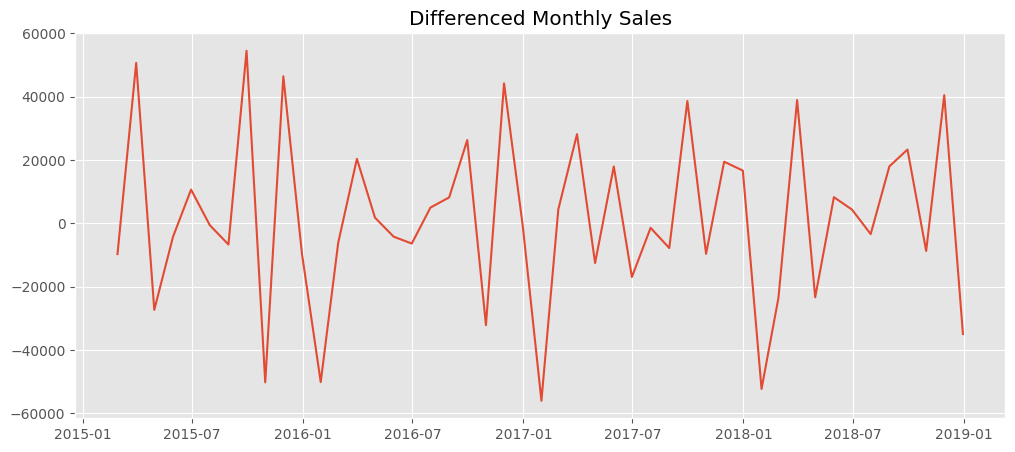

In [448]:
#plotting the differenced series
plt.figure(figsize=(12,5))
plt.plot(monthly_diff)
plt.title("Differenced Monthly Sales")
plt.savefig(
    "differenced_monthly_sales.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

In [449]:
#ADF TEST AGAIN
result2 = adfuller(monthly_diff)

print("ADF Statistic:", result2[0])
print("p-value:", result2[1])

for key,value in result2[4].items():
    print(key,":",value)

ADF Statistic: -8.727061830353268
p-value: 3.2669175472796045e-14
1% : -3.626651907578875
5% : -2.9459512825788754
10% : -2.6116707716049383


# Task 3 — Sales Forecasting using 3 Different Models


*  # Model 1 — SARIMA (Statistical Model)


In [450]:
#importing the libraries
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

In [451]:
monthly_sales = sales.groupby(pd.Grouper(key="Order Date", freq="M"))["Sales"].sum()

In [452]:
#train test split
train = monthly_sales[:-3]
test = monthly_sales[-3:]

In [453]:
# BUILD SARIMA MODEL
model = SARIMAX(train, order=(1,1,1), seasonal_order=(1,1,1,12))

sarima_model = model.fit()

The parameters (1,1,1) and seasonal (1,1,1,12) were selected as a reasonable starting configuration for monthly sales data.

p = 1: One autoregressive term captures dependence on the previous month's sales.

d = 1: First-order differencing helps stabilize the series if a trend is present.

q = 1: One moving average term captures recent forecast errors.

Seasonal period (m = 12): Sales are monthly, so yearly seasonality is modeled over 12 months.

In [454]:
#Forecast for next 3 months
forecast = sarima_model.get_forecast(steps=3)

forecast_values = forecast.predicted_mean

confidence = forecast.conf_int()

In [455]:
print(forecast_values)

2018-10-31    66177.602425
2018-11-30    92049.249682
2018-12-31    99965.168723
Freq: ME, Name: predicted_mean, dtype: float64


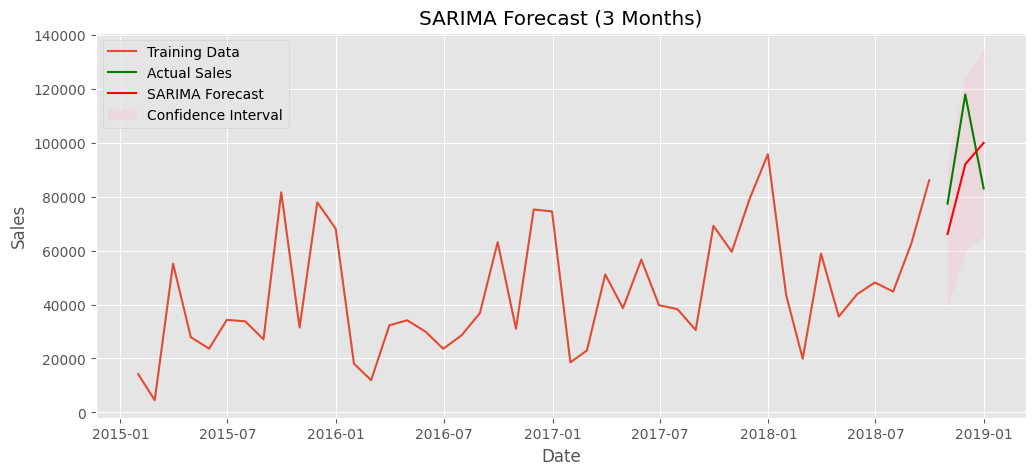

In [456]:
#plotting Actual vs Forecast
plt.figure(figsize=(12,5))

plt.plot(train.index, train, label="Training Data")

plt.plot(test.index, test, label="Actual Sales", color="green")

plt.plot(forecast_values.index, forecast_values,
         label="SARIMA Forecast",
         color="red")

plt.fill_between(
    confidence.index,
    confidence.iloc[:,0],
    confidence.iloc[:,1],
    color="pink",
    alpha=0.3,
    label="Confidence Interval"
)

plt.title("SARIMA Forecast (3 Months)")
plt.xlabel("Date")
plt.ylabel("Sales")
plt.legend()
plt.savefig(
    "SARIMA_Forecast.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

In [457]:
#evaluate
mae = mean_absolute_error(test, forecast_values)
rmse = np.sqrt(mean_squared_error(test, forecast_values))
mape = np.mean(np.abs((test - forecast_values) / test)) * 100

print("MAE :", mae)
print("RMSE :", rmse)
print("MAPE :", mape)

MAE : 18031.40467222437
RMSE : 19009.18206635205
MAPE : 18.966498068433015


* # Model 2 — Facebook Prophet (Industry-standard Forecasting Tool)


In [458]:
!pip uninstall prophet -y
!pip install prophet
!pip install cmdstanpy

Found existing installation: prophet 1.3.0
Uninstalling prophet-1.3.0:
  Successfully uninstalled prophet-1.3.0
  Using cached prophet-1.3.0-py3-none-manylinux2014_x86_64.manylinux_2_17_x86_64.whl.metadata (3.5 kB)
Using cached prophet-1.3.0-py3-none-manylinux2014_x86_64.manylinux_2_17_x86_64.whl (12.1 MB)


In [459]:
from prophet import Prophet

In [460]:
#prepare data ds(date) and y(target)
prophet_data = monthly_sales.reset_index()

prophet_data.columns = ["ds", "y"]

prophet_data.head()

,ds,y
0,2015-01-31,14205.707
1,2015-02-28,4519.892
2,2015-03-31,55205.797
3,2015-04-30,27906.855
4,2015-05-31,23644.303


In [461]:
print(train.dtypes)

float64


In [462]:
train.info()

<class 'pandas.core.series.Series'>
DatetimeIndex: 45 entries, 2015-01-31 to 2018-09-30
Freq: ME
Series name: Sales
Non-Null Count  Dtype  
--------------  -----  
45 non-null     float64
dtypes: float64(1)
memory usage: 720.0 bytes


In [463]:
train.isnull().sum()

np.int64(0)

In [464]:
print(train.head())

print(train.dtypes)

print(train.shape)

Order Date
2015-01-31    14205.707
2015-02-28     4519.892
2015-03-31    55205.797
2015-04-30    27906.855
2015-05-31    23644.303
Freq: ME, Name: Sales, dtype: float64
float64
(45,)


In [465]:
#train test split
train = prophet_data[:-3]
test = prophet_data[-3:]

In [466]:
#build prophet model
model = Prophet()
model.fit(train)

INFO:prophet:Disabling weekly seasonality. Run prophet with weekly_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.


In [467]:
#future dataframes (3 months) forecast
future = model.make_future_dataframe(periods=3, freq="M")

In [468]:
#forecast
forecast = model.predict(future)

forecast.tail()

,ds,trend,yhat_lower,yhat_upper,trend_lower,trend_upper,additive_terms,additive_terms_lower,additive_terms_upper,yearly,yearly_lower,yearly_upper,multiplicative_terms,multiplicative_terms_lower,multiplicative_terms_upper,yhat
43,2018-08-31,54942.277762,38917.065883,55479.274015,54942.277762,54942.277762,-7670.719569,-7670.719569,-7670.719569,-7670.719569,-7670.719569,-7670.719569,0.0,0.0,0.0,47271.558193
44,2018-09-30,55441.608151,78306.879061,94445.858564,55441.608151,55441.608151,31172.345120,31172.345120,31172.345120,31172.345120,31172.345120,31172.345120,0.0,0.0,0.0,86613.953271
45,2018-10-31,55957.582886,42985.660696,59775.858334,55957.426560,55957.721473,-4638.639074,-4638.639074,-4638.639074,-4638.639074,-4638.639074,-4638.639074,0.0,0.0,0.0,51318.943812
46,2018-11-30,56456.913275,82323.660490,98565.292380,56456.397202,56457.383526,33868.741461,33868.741461,33868.741461,33868.741461,33868.741461,33868.741461,0.0,0.0,0.0,90325.654736
47,2018-12-31,56972.888010,81587.139634,98084.124045,56971.844604,56973.836988,33068.196420,33068.196420,33068.196420,33068.196420,33068.196420,33068.196420,0.0,0.0,0.0,90041.084430


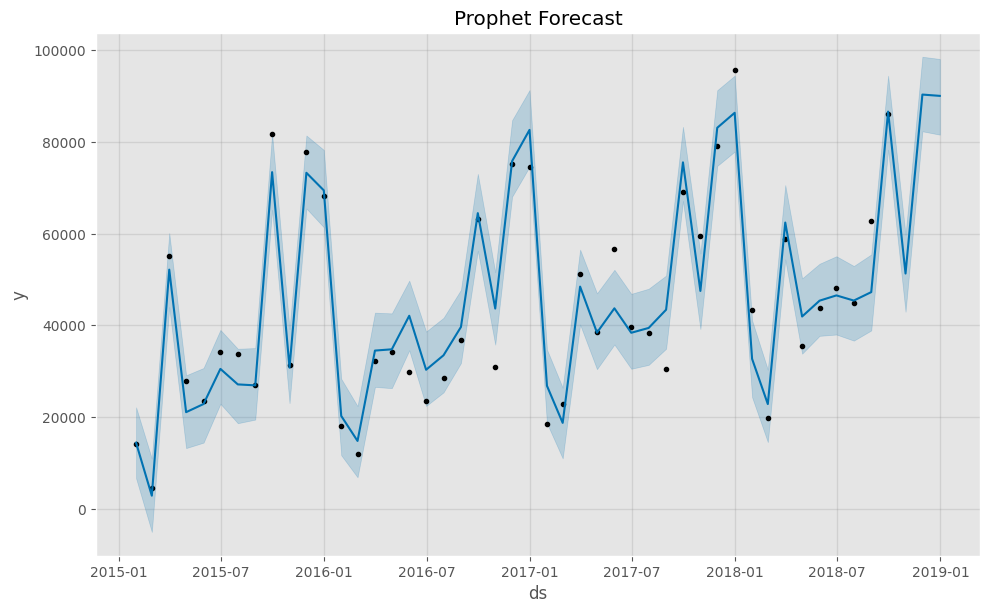

In [469]:
#forecast plot
fig1 = model.plot(forecast)
plt.title("Prophet Forecast")
plt.savefig(
    "Prophet_Forecast.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

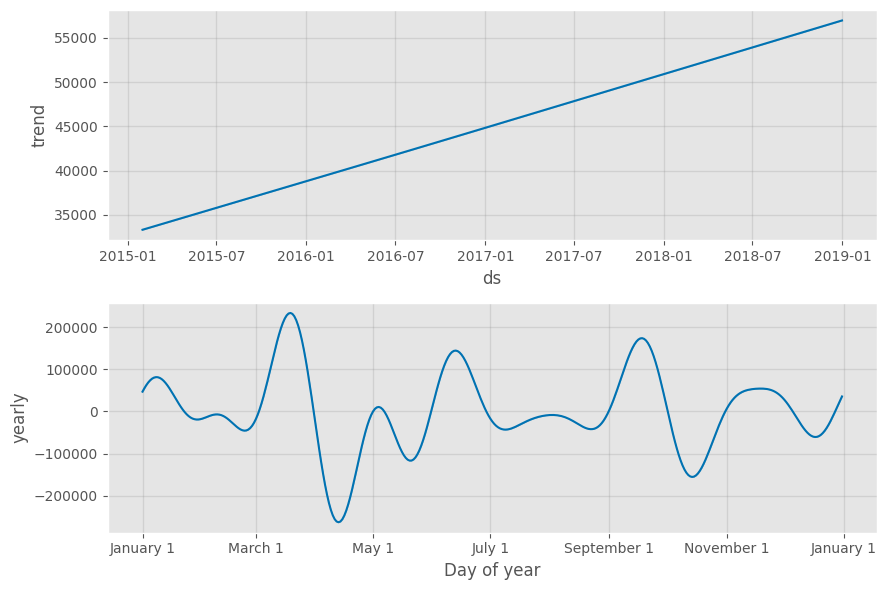

In [470]:
#Trend and Seasonality
fig2 = model.plot_components(forecast)
plt.savefig(
    "trend and seasonality.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

In [471]:
#last 3 months predictions
forecast_3 = forecast[["ds","yhat"]].tail(3)

print(forecast_3)

           ds          yhat
45 2018-10-31  51318.943812
46 2018-11-30  90325.654736
47 2018-12-31  90041.084430


Weekly Seasonality :

Since the model was trained on monthly aggregated sales data, Prophet does not estimate meaningful weekly seasonality. Weekly patterns require daily or higher-frequency observations. Therefore, no significant weekly seasonal trend is observed in this analysis.

Yearly Seasonality :

The yearly seasonality component indicates recurring sales patterns over the course of a year. Sales tend to increase during the final months of the year, reflecting higher customer demand during festive seasons, holiday shopping, and promotional events. This confirms the presence of strong annual seasonality in the sales data.

In [472]:
#evaluation
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

pred = forecast["yhat"].tail(3).values

actual = test["y"].values

mae = mean_absolute_error(actual, pred)
rmse = np.sqrt(mean_squared_error(actual, pred))
mape = np.mean(np.abs((actual-pred)/actual))*100

In [473]:
print("MAE :", mae)
print("RMSE :", rmse)
print("MAPE :", mape)

MAE : 20250.794427610937
RMSE : 22318.41136551923
MAPE : 21.864628287701436


* # Model 3 — XGBoost for Time Series (ML-based Approach)

In [474]:
!pip install xgboost

In [475]:
#importing
import xgboost as xgb
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np
from xgboost import XGBRegressor

import pandas as pd
import matplotlib.pyplot as plt

In [476]:
#Monthly Sales Data
monthly_sales = sales.groupby(pd.Grouper(key="Order Date", freq="M"))["Sales"].sum().reset_index()
monthly_sales.head()

,Order Date,Sales
0,2015-01-31,14205.707
1,2015-02-28,4519.892
2,2015-03-31,55205.797
3,2015-04-30,27906.855
4,2015-05-31,23644.303


In [477]:
#creating the features
#convert time series in supervised learning

df = monthly_sales.copy()

# Lag Features
df["Lag1"] = df["Sales"].shift(1)
df["Lag2"] = df["Sales"].shift(2)
df["Lag3"] = df["Sales"].shift(3)

# Rolling Mean
df["RollingMean"] = df["Sales"].rolling(3).mean()

# Time Features
df["Month"] = df["Order Date"].dt.month
df["Quarter"] = df["Order Date"].dt.quarter

# Season
def season(month):
    if month in [12,1,2]:
        return 1      # Winter
    elif month in [3,4,5]:
        return 2      # Spring
    elif month in [6,7,8]:
        return 3      # Summer
    else:
        return 4      # Autumn

df["Season"] = df["Month"].apply(season)

df["Season"] = df["Month"].replace({
    12:1,1:1,2:1,
    3:2,4:2,5:2,
    6:3,7:3,8:3,
    9:4,10:4,11:4
})



In [478]:
df[["Order Date", "Sales", "Month", "Quarter", "Season"]].head(10)
print(df.head())

  Order Date      Sales       Lag1       Lag2       Lag3   RollingMean  Month  \
0 2015-01-31  14205.707        NaN        NaN        NaN           NaN      1   
1 2015-02-28   4519.892  14205.707        NaN        NaN           NaN      2   
2 2015-03-31  55205.797   4519.892  14205.707        NaN  24643.798667      3   
3 2015-04-30  27906.855  55205.797   4519.892  14205.707  29210.848000      4   
4 2015-05-31  23644.303  27906.855  55205.797   4519.892  35585.651667      5   

   Quarter  Season  
0        1       1  
1        1       1  
2        1       2  
3        2       2  
4        2       2  


In [479]:
df = df.dropna()

df.head()

,Order Date,Sales,Lag1,Lag2,Lag3,RollingMean,Month,Quarter,Season
3,2015-04-30,27906.8550,55205.7970,4519.8920,14205.707,29210.848000,4,2,2
4,2015-05-31,23644.3030,27906.8550,55205.7970,4519.892,35585.651667,5,2,2
5,2015-06-30,34322.9356,23644.3030,27906.8550,55205.797,28624.697867,6,2,3
6,2015-07-31,33781.5430,34322.9356,23644.3030,27906.855,30582.927200,7,3,3
7,2015-08-31,27117.5365,33781.5430,34322.9356,23644.303,31740.671700,8,3,3


In [480]:
# FEATURES AND TARGETS
x = df[[
    "Lag1",
    "Lag2",
    "Lag3",
    "RollingMean",
    "Month",
    "Quarter",
    "Season"
]]

y = df["Sales"]

In [481]:
#train test split
x_train = x[:-3]
x_test = x[-3:]

y_train = y[:-3]
y_test = y[-3:]

In [482]:
# Train the XGBoost Model
model = xgb.XGBRegressor(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=3,
    random_state=42)

model.fit(x_train, y_train)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=True, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.1, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=3,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=100,
             n_jobs=None, num_parallel_tree=None, ...)

In [483]:
#predict next 3 months
pred = model.predict(x_test)
pred

array([86465.82, 86506.77, 84327.28], dtype=float32)

In [484]:
#Metrics
mae = mean_absolute_error(y_test, pred)
rmse = np.sqrt(mean_squared_error(y_test, pred))
mape = np.mean(np.abs((y_test-pred)/y_test))*100

print("MAE :",mae)
print("RMSE :",rmse)
print("MAPE :",mape)

MAE : 13915.321041666664
RMSE : 18893.847269098238
MAPE : 13.285400568532047


In [485]:
forecast_xgb = pd.DataFrame({
    "Date": monthly_sales["Order Date"].iloc[-3:].values,
    "Forecast": pred
})

forecast_xgb

,Date,Forecast
0,2018-10-31,86465.820312
1,2018-11-30,86506.773438
2,2018-12-31,84327.281250


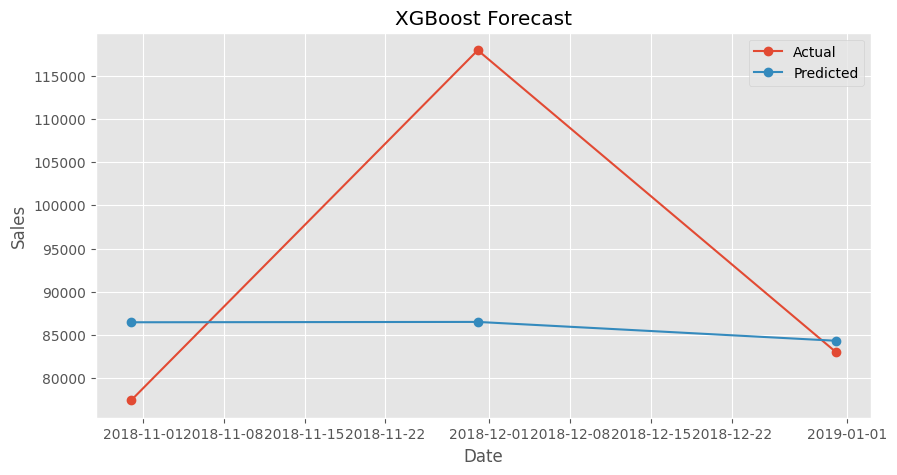

In [535]:
#plot
plt.figure(figsize=(10,5))

plt.plot(
    monthly_sales["Order Date"].iloc[-3:],
    y_test,
    marker="o",
    label="Actual"
)

plt.plot(
    monthly_sales["Order Date"].iloc[-3:],
    pred,
    marker="o",
    label="Predicted"
)
plt.title("XGBoost Forecast")
plt.xlabel("Date")
plt.ylabel("Sales")
plt.legend()
plt.savefig(
    "XGBoost_Forecast.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

In [487]:
comparison = pd.DataFrame({
    "Model": ["SARIMA", "Prophet", "XGBoost"],
    "MAE": [18031.40, 20250.79, 13915.32],
    "RMSE": [19009.18, 22318.41, 18893.85],
    "MAPE (%)": [18.97, 21.86, 13.29],
    "Forecast Month 1": [66177.60, 51318.94, 86465.82],
    "Forecast Month 2": [92049.25, 90325.65, 86506.77],
    "Forecast Month 3": [99965.17, 90041.08, 84327.28]
})

comparison

,Model,MAE,RMSE,MAPE (%),Forecast Month 1,Forecast Month 2,Forecast Month 3
0,SARIMA,18031.40,19009.18,18.97,66177.60,92049.25,99965.17
1,Prophet,20250.79,22318.41,21.86,51318.94,90325.65,90041.08
2,XGBoost,13915.32,18893.85,13.29,86465.82,86506.77,84327.28


| Model | MAE | RMSE | MAPE (%) | Forecast Month 1 | Forecast Month 2 | Forecast Month 3 |
|-------|------:|------:|------:|------:|------:|------:|
| SARIMA | 18031.40 | 19009.18 | 18.97 | 66177.60 | 92049.25 | 99965.17 |
| Prophet | 20250.79 | 22318.41 | 21.86 | 51318.94 | 90325.65 | 90041.08 |
| XGBoost | 13915.32 | 18893.85 | 13.29 | 86465.82 | 86506.77 | 84327.28 |

Model Recommendation :

Based on the evaluation metrics, XGBoost is recommended for production use because it achieved the best overall forecasting performance among the three models.

It recorded the lowest MAE (13,915.32), the lowest RMSE (18,893.85), and the lowest MAPE (13.29%), indicating the highest prediction accuracy. In comparison, SARIMA achieved an MAE of 18,031.40 and a MAPE of 18.97%, while Prophet produced the highest errors with an MAE of 20,250.79 and a MAPE of 21.86%.

 Therefore, XGBoost is the most suitable model for deployment as it provides the most accurate sales forecasts for inventory planning and demand forecasting.

# Task 4 — Product Category & Region Level Forecasting


In [488]:
import pandas as pd
import numpy as np
import xgboost as xgb

In [489]:
#create a function
def xgb_forecast(data):

    monthly = data.groupby(
        pd.Grouper(key="Order Date", freq="ME")
    )["Sales"].sum().reset_index()

    df = monthly.copy()

    df["Lag1"] = df["Sales"].shift(1)
    df["Lag2"] = df["Sales"].shift(2)
    df["Lag3"] = df["Sales"].shift(3)

    df["RollingMean"] = df["Sales"].rolling(3).mean()

    df["Month"] = df["Order Date"].dt.month
    df["Quarter"] = df["Order Date"].dt.quarter

    def season(m):
        if m in [12,1,2]:
            return 1
        elif m in [3,4,5]:
            return 2
        elif m in [6,7,8]:
            return 3
        else:
            return 4

    df["Season"] = df["Month"].apply(season)

    df = df.dropna()

    X = df[[
        "Lag1",
        "Lag2",
        "Lag3",
        "RollingMean",
        "Month",
        "Quarter",
        "Season"
    ]]

    y = df["Sales"]

    X_train = X[:-3]
    X_test = X[-3:]

    y_train = y[:-3]

    model = xgb.XGBRegressor(
        n_estimators=100,
        learning_rate=0.1,
        max_depth=3,
        random_state=42
    )

    model.fit(X_train,y_train)

    pred = model.predict(X_test)

    return pred

In [490]:
#Furniture

furniture = sales[sales["Category"] == "Furniture"]

furniture_pred = xgb_forecast(furniture)

print("Furniture Forecast")
print(furniture_pred)

Furniture Forecast
[23439.756 34192.125 35541.227]


In [491]:
#Technology

technology = sales[sales["Category"] == "Technology"]

technology_pred = xgb_forecast(technology)

print("Technology Forecast")
print(technology_pred)

Technology Forecast
[26031.355 26649.729 22516.584]


In [492]:
#Office Supplies

office = sales[sales["Category"] == "Office Supplies"]

office_pred = xgb_forecast(office)

print("Office Supplies Forecast")
print(office_pred)

Office Supplies Forecast
[26665.988 26778.512 26560.111]


In [493]:
# West region

west = sales[sales["Region"] == "West"]

west_pred = xgb_forecast(west)

print("West Region Forecast")
print(west_pred)

West Region Forecast
[17816.506 19530.713 28989.953]


In [494]:
# East region

east = sales[sales["Region"] == "East"]

east_pred = xgb_forecast(east)

print("East Region Forecast")
print(east_pred)

East Region Forecast
[20672.438 21855.973 22969.379]


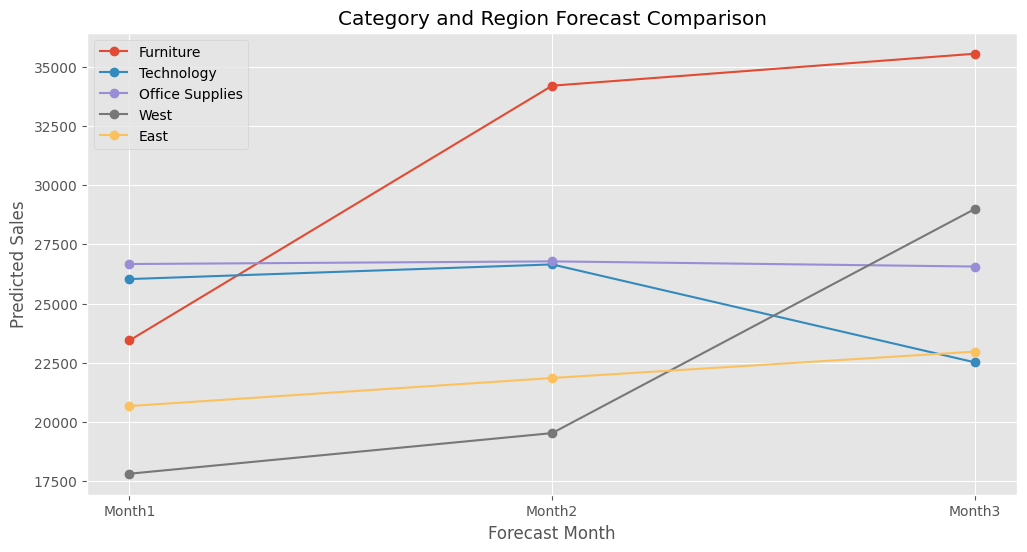

In [536]:
# Ploting on comparison chart

plt.figure(figsize=(12,6))

months=["Month1","Month2","Month3"]
plt.plot(months,furniture_pred,marker="o",label="Furniture")
plt.plot(months,technology_pred,marker="o",label="Technology")
plt.plot(months,office_pred,marker="o",label="Office Supplies")
plt.plot(months,west_pred,marker="o",label="West")
plt.plot(months,east_pred,marker="o",label="East")
plt.title("Category and Region Forecast Comparison")
plt.xlabel("Forecast Month")
plt.ylabel("Predicted Sales")
plt.legend()
plt.grid(True)
plt.savefig(
    "category_and_region_forecast.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

Observation :         
               
According to the XGBoost forecasting model, the Furniture category is expected to show the strongest upcoming growth among all product categories. Its predicted sales increase significantly across the three forecast months, indicating rising demand.

 Among the regions, the West region is projected to experience the highest growth, with sales increasing sharply by the third forecast month.

 In contrast, Technology shows a slight decline in the final month, Office Supplies remains relatively stable, and the East region demonstrates only gradual growth.

# Task 5 — Anomaly Detection in Sales Data

In [496]:
from sklearn.ensemble import IsolationForest
from scipy.stats import zscore
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

In [497]:
#weekly sales

weekly_sales = sales.groupby(pd.Grouper(key="Order Date", freq="W"))["Sales"].sum().reset_index()

weekly_sales.head()

,Order Date,Sales
0,2015-01-04,304.508
1,2015-01-11,4619.108
2,2015-01-18,4130.533
3,2015-01-25,3092.544
4,2015-02-01,2527.914


In [498]:
#Isolation Forest
iso = IsolationForest(
    contamination=0.05,
    random_state=42)

weekly_sales["Anomaly"] = iso.fit_predict(
    weekly_sales[["Sales"]])

weekly_sales.head()

,Order Date,Sales,Anomaly
0,2015-01-04,304.508,-1
1,2015-01-11,4619.108,1
2,2015-01-18,4130.533,1
3,2015-01-25,3092.544,1
4,2015-02-01,2527.914,1


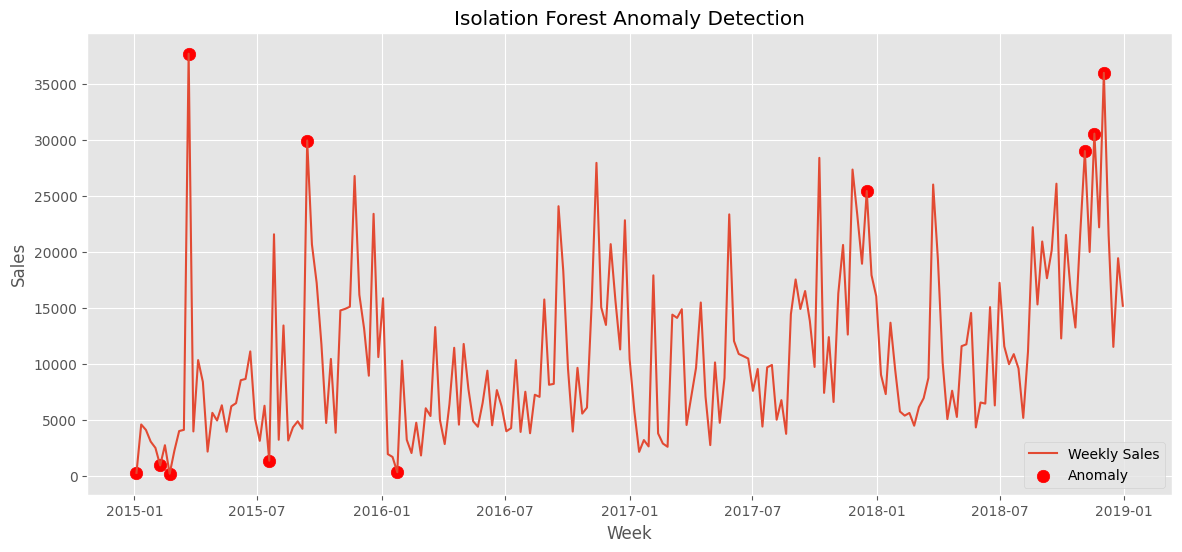

In [537]:
#plot
plt.figure(figsize=(14,6))

plt.plot(
    weekly_sales["Order Date"],
    weekly_sales["Sales"],
    label="Weekly Sales"
)

anomalies = weekly_sales[
    weekly_sales["Anomaly"]==-1
]

plt.scatter(
    anomalies["Order Date"],
    anomalies["Sales"],
    color="red",
    s=80,
    label="Anomaly"
)

plt.title("Isolation Forest Anomaly Detection")
plt.xlabel("Week")
plt.ylabel("Sales")
plt.legend()
plt.savefig(
    "Isolation_Forest_Anamoly_detection.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

In [500]:
#print anomalies
print(anomalies)

    Order Date      Sales  Anomaly
0   2015-01-04    304.508       -1
5   2015-02-08    968.534       -1
7   2015-02-22    224.912       -1
11  2015-03-22  37703.665       -1
28  2015-07-19   1387.686       -1
36  2015-09-13  29959.137       -1
55  2016-01-24    358.522       -1
154 2017-12-17  25449.800       -1
200 2018-11-04  29017.467       -1
202 2018-11-18  30572.447       -1
204 2018-12-02  35998.900       -1


In [501]:
#total
print("Total anomalies detected:", len(anomalies))

Total anomalies detected: 11


Isolation Forest :

Isolation Forest identified weeks with unusually high or low sales compared to the overall sales pattern. These anomalies may correspond to festive season promotions, special discount campaigns, inventory shortages, or unexpected market events.

In [502]:
print(anomalies[["Order Date", "Sales"]])

    Order Date      Sales
0   2015-01-04    304.508
5   2015-02-08    968.534
7   2015-02-22    224.912
11  2015-03-22  37703.665
28  2015-07-19   1387.686
36  2015-09-13  29959.137
55  2016-01-24    358.522
154 2017-12-17  25449.800
200 2018-11-04  29017.467
202 2018-11-18  30572.447
204 2018-12-02  35998.900


The detected anomalies represent weeks where sales were significantly different from the normal sales pattern. High-sales anomalies are likely associated with festive seasons, promotional campaigns, or special discount events, while unusually low-sales weeks may be caused by inventory shortages, supply chain disruptions, seasonal declines in demand, or operational issues. These anomalies highlight periods that require further business investigation before making inventory or forecasting decisions.

Isolation Forest detected both unusually high and unusually low sales weeks. High-sales anomalies mainly occurred during late 2017 and late 2018, which are likely associated with festive seasons, promotional campaigns, and year-end shopping. Low-sales anomalies were observed in early 2015 and early 2016, possibly due to post-holiday demand decline, seasonal slowdowns, or inventory-related issues. These anomalies represent important business events that should be investigated before making inventory or demand planning decisions.

2015-09-13 :- High sales week, which may be associated with promotional events or increased customer purchases.

2018-11-04 :- High sales, possibly influenced by festive season promotions and increased customer demand.

2016-01-24 :- Very low sales, likely due to post-holiday demand decline or inventory-related issues.

2018-12-02 :- Peak sales period, most likely associated with Christmas and year-end purchasing activity.

In [503]:
# ROLLING MEAN

weekly_sales["RollingMean"] = (
    weekly_sales["Sales"]
    .rolling(4)
    .mean())

In [504]:
# ROLLING STD
weekly_sales["RollingStd"] = (
    weekly_sales["Sales"]
    .rolling(4)
    .std())

In [505]:
# Z SCORE
weekly_sales["Z"] = (
    weekly_sales["Sales"]-
    weekly_sales["RollingMean"])/weekly_sales["RollingStd"]

In [506]:
#flag the anomalies
weekly_sales["Z_Anomaly"] = (
    abs(weekly_sales["Z"])>2)

In [507]:
weekly_sales[
    weekly_sales["Z_Anomaly"]
]

,Order Date,Sales,Anomaly,RollingMean,RollingStd,Z,Z_Anomaly


In [508]:
z_anomalies = weekly_sales[
    weekly_sales["Z_Anomaly"]
]

print(z_anomalies)

Empty DataFrame
Columns: [Order Date, Sales, Anomaly, RollingMean, RollingStd, Z, Z_Anomaly]
Index: []


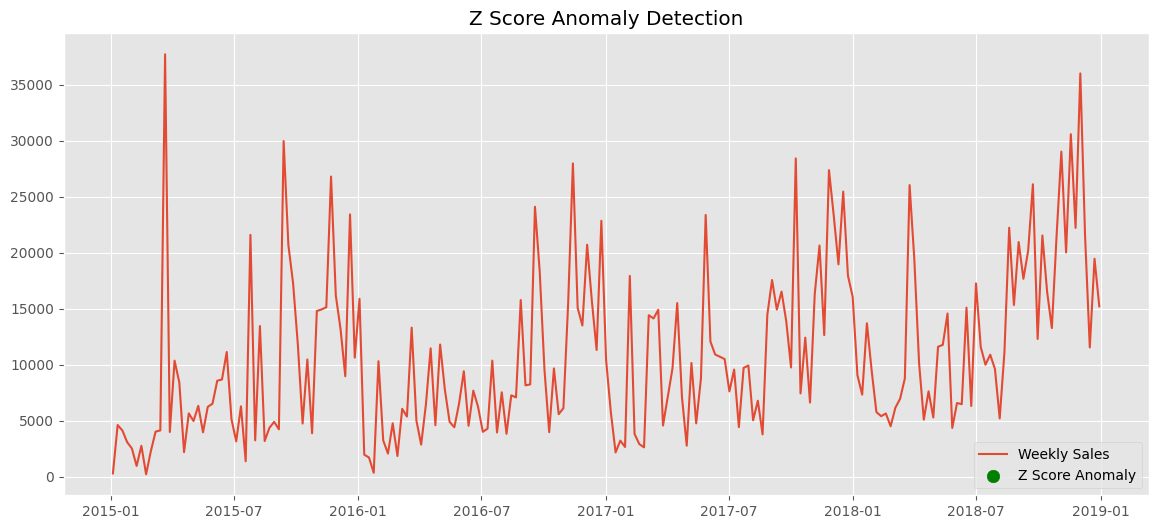

In [538]:
#plot
plt.figure(figsize=(14,6))

plt.plot(
    weekly_sales["Order Date"],
    weekly_sales["Sales"],
    label="Weekly Sales"
)

z = weekly_sales[
    weekly_sales["Z_Anomaly"]
]

plt.scatter(
    z["Order Date"],
    z["Sales"],
    color="green",
    s=80,
    label="Z Score Anomaly"
)

plt.title("Z Score Anomaly Detection")
plt.legend()
plt.savefig(
    "ZScore_Anamoly_Detection.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

In [510]:
print("Isolation Forest :",len(anomalies))

print("Z Score :",len(z))

Isolation Forest : 11
Z Score : 0


In [511]:
print(len(anomalies))
print(len(z_anomalies))

11
0


In [512]:
print(z_anomalies[["Order Date","Sales"]])

Empty DataFrame
Columns: [Order Date, Sales]
Index: []


The two methods do not identify or Flag the same anomalies. Isolation Forest detected 11 anomalous weeks, whereas the Z-Score method did not detect any anomalies using a threshold of ±2 standard deviations from the rolling mean. This indicates that Isolation Forest is more sensitive to unusual sales patterns because it considers the overall data distribution, while the Z-Score method only flags observations that are statistically extreme relative to the rolling mean. In this dataset, the weekly sales did not exceed the chosen Z-Score threshold, resulting in no anomalies being detected by the statistical method.

Therefore, Isolation Forest was better suited for detecting anomalies in this weekly sales dataset.

In [513]:
#vgsales
vgsales = pd.read_csv("vgsales.csv")

vgsales.head()

,Rank,Name,Platform,Year,Genre,Publisher,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales
0,1,Wii Sports,Wii,2006.0,Sports,Nintendo,41.49,29.02,3.77,8.46,82.74
1,2,Super Mario Bros.,NES,1985.0,Platform,Nintendo,29.08,3.58,6.81,0.77,40.24
2,3,Mario Kart Wii,Wii,2008.0,Racing,Nintendo,15.85,12.88,3.79,3.31,35.82
3,4,Wii Sports Resort,Wii,2009.0,Sports,Nintendo,15.75,11.01,3.28,2.96,33.00
4,5,Pokemon Red/Pokemon Blue,GB,1996.0,Role-Playing,Nintendo,11.27,8.89,10.22,1.00,31.37


In [514]:
print(vgsales.info())

print(vgsales.shape)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16598 entries, 0 to 16597
Data columns (total 11 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Rank          16598 non-null  int64  
 1   Name          16598 non-null  object 
 2   Platform      16598 non-null  object 
 3   Year          16327 non-null  float64
 4   Genre         16598 non-null  object 
 5   Publisher     16540 non-null  object 
 6   NA_Sales      16598 non-null  float64
 7   EU_Sales      16598 non-null  float64
 8   JP_Sales      16598 non-null  float64
 9   Other_Sales   16598 non-null  float64
 10  Global_Sales  16598 non-null  float64
dtypes: float64(6), int64(1), object(4)
memory usage: 1.4+ MB
None
(16598, 11)


The supplementary dataset was explored to demonstrate handling multiple data sources. Since the two datasets have different business domains and no common join key  (such as Product ID, Date, Category, or Region), they were analyzed independently rather than merged. The anomaly detection task was performed on the Superstore weekly sales dataset because it directly represents the forecasting problem.

 # Task 6 — Product Demand Segmentation using Clustering

In [515]:
# Clustering & Anomaly Detection
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import IsolationForest
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

In [516]:
# Extract Year
sales["Year"] = sales["Order Date"].dt.year

In [517]:
# Aggregate at Product Sub-Category level
sales["Year"] = sales["Order Date"].dt.year

subcategory = sales.groupby(["Sub-Category","Year"]).agg(
    Total_Sales=("Sales","sum"),
    Avg_Order_Value=("Sales","mean")
).reset_index()

In [518]:
#Sales Growth Rate
subcategory["Growth_Rate"] = (
    subcategory.groupby("Sub-Category")["Total_Sales"]
    .pct_change()
)

In [519]:
# Sales Volatility
monthly = sales.groupby(
    ["Sub-Category", pd.Grouper(key="Order Date", freq="ME")]
)["Sales"].sum().reset_index()

volatility = monthly.groupby("Sub-Category")["Sales"].std().reset_index()

volatility.columns = ["Sub-Category","Volatility"]

In [520]:
#Avg order value
avg_order_value = sales.groupby("Sub-Category")["Sales"].mean()

print(avg_order_value)

Sub-Category
Accessories     217.178175
Appliances      227.926804
Art              34.019631
Binders         134.067550
Bookcases       503.598224
Chairs          531.833165
Copiers        2215.880212
Envelopes        65.032444
Fasteners        14.027850
Furnishings      95.823865
Labels           34.587468
Machines       1645.553313
Paper            57.420257
Phones          374.180877
Storage         263.633885
Supplies        252.284283
Tables          645.893720
Name: Sales, dtype: float64


In [521]:
cluster_data = sales.groupby("Sub-Category").agg(
    Total_Sales=("Sales", "sum"),
    Average_Order_Value=("Sales", "mean")
).reset_index()

In [522]:
#Final Dataset
cluster_data = subcategory.groupby("Sub-Category").agg(
    Total_Sales=("Total_Sales","sum"),
    Growth_Rate=("Growth_Rate","mean"),
    Avg_Order_Value=("Avg_Order_Value","mean")
).reset_index()

cluster_data = cluster_data.merge(
    volatility,
    on="Sub-Category"
)

cluster_data.fillna(0,inplace=True)

cluster_data

,Sub-Category,Total_Sales,Growth_Rate,Avg_Order_Value,Volatility
0,Accessories,164186.7000,0.376381,214.861154,2579.994809
1,Appliances,104618.4030,0.399276,223.640315,1821.621539
2,Art,26705.4100,0.166056,34.466263,330.488343
3,Binders,200028.7850,0.218736,133.849772,3848.223648
4,Bookcases,113813.1987,0.238065,514.592607,2220.405080
5,Chairs,322822.7310,0.071358,537.126786,4407.232960
6,Copiers,146248.0940,0.846718,2140.386912,5500.774391
7,Envelopes,16128.0460,-0.027666,66.023946,228.218688
8,Fasteners,3001.9600,0.157034,13.913598,48.742229
9,Furnishings,89212.0180,0.287889,95.277349,1360.017867


In [523]:
from sklearn.preprocessing import StandardScaler

features = cluster_data[
    [
        "Total_Sales",
        "Growth_Rate",
        "Volatility",
        "Avg_Order_Value"
    ]
]

scaler = StandardScaler()

scaled_features = scaler.fit_transform(features)

In [524]:
#Apply K MEANS
from sklearn.cluster import KMeans

kmeans = KMeans(
    n_clusters=4,
    random_state=42,
    n_init=10
)

cluster_data["Cluster"] = kmeans.fit_predict(scaled_features)

In [525]:
#result
cluster_data

,Sub-Category,Total_Sales,Growth_Rate,Avg_Order_Value,Volatility,Cluster
0,Accessories,164186.7000,0.376381,214.861154,2579.994809,2
1,Appliances,104618.4030,0.399276,223.640315,1821.621539,1
2,Art,26705.4100,0.166056,34.466263,330.488343,1
3,Binders,200028.7850,0.218736,133.849772,3848.223648,2
4,Bookcases,113813.1987,0.238065,514.592607,2220.405080,1
5,Chairs,322822.7310,0.071358,537.126786,4407.232960,2
6,Copiers,146248.0940,0.846718,2140.386912,5500.774391,0
7,Envelopes,16128.0460,-0.027666,66.023946,228.218688,1
8,Fasteners,3001.9600,0.157034,13.913598,48.742229,1
9,Furnishings,89212.0180,0.287889,95.277349,1360.017867,1


In [526]:
cluster_data[[
    "Sub-Category",
    "Cluster"
]]

,Sub-Category,Cluster
0,Accessories,2
1,Appliances,1
2,Art,1
3,Binders,2
4,Bookcases,1
5,Chairs,2
6,Copiers,0
7,Envelopes,1
8,Fasteners,1
9,Furnishings,1


In [527]:
# Elbow Method
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

wcss = []

for i in range(1, 11):
    kmeans = KMeans(
        n_clusters=i,
        random_state=42,
        n_init=10
    )
    kmeans.fit(scaled_features)
    wcss.append(kmeans.inertia_)

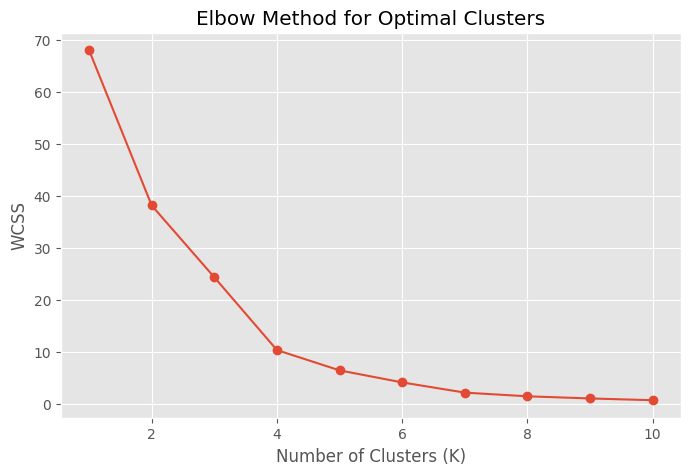

In [539]:
#ploting the elbow graph

plt.figure(figsize=(8,5))

plt.plot(range(1,11), wcss, marker="o")

plt.title("Elbow Method for Optimal Clusters")

plt.xlabel("Number of Clusters (K)")

plt.ylabel("WCSS")

plt.grid(True)
plt.savefig(
    "elbow_method.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [529]:
cluster_data

,Sub-Category,Total_Sales,Growth_Rate,Avg_Order_Value,Volatility,Cluster
0,Accessories,164186.7000,0.376381,214.861154,2579.994809,2
1,Appliances,104618.4030,0.399276,223.640315,1821.621539,1
2,Art,26705.4100,0.166056,34.466263,330.488343,1
3,Binders,200028.7850,0.218736,133.849772,3848.223648,2
4,Bookcases,113813.1987,0.238065,514.592607,2220.405080,1
5,Chairs,322822.7310,0.071358,537.126786,4407.232960,2
6,Copiers,146248.0940,0.846718,2140.386912,5500.774391,0
7,Envelopes,16128.0460,-0.027666,66.023946,228.218688,1
8,Fasteners,3001.9600,0.157034,13.913598,48.742229,1
9,Furnishings,89212.0180,0.287889,95.277349,1360.017867,1


The Elbow Method indicates that the optimal number of clusters is 4. After K = 4, the decrease in WCSS becomes much smaller, indicating diminishing returns from adding more clusters. Therefore, K = 4 was selected for K-Means clustering.

In [530]:
kmeans = KMeans(
    n_clusters=4,
    random_state=42,
    n_init=10
)

cluster_data["Cluster"] = kmeans.fit_predict(scaled)

Cluster 0 – High Value, High Volatility

Copiers,
Machines

Reason:
* Very high average order value
* High sales volatility

Cluster 1 – Low Volume, Stable Demand

Appliances,
Art,
Bookcases,
Envelopes,
Fasteners,
Furnishings,
Labels,
Paper.

Reason:

* Lower total sales
* Comparatively stable demand
* Lower volatility

Cluster 2 – High Volume, Stable Demand

Accessories,
Binders,
Chairs,
Phones,
Storage,
Tables.

Reason:

* Highest total sales
* Consistent demand across years

Cluster 3 – Growing Demand

Supplies

Reason:

* Highest growth rate (≈1.93)
* Strong upward trend despite moderate sales volume

K-Means clustering grouped the product sub-categories into four distinct demand segments. Cluster 2 contains high-volume products with relatively stable demand, making them the primary revenue drivers. Cluster 0 includes premium products with high order values and higher sales volatility. Cluster 1 consists of lower-volume products with comparatively stable demand, while Cluster 3 represents products with rapidly growing demand that may require increased inventory planning.

In [531]:
#PCA
from sklearn.decomposition import PCA

pca = PCA(n_components=2)

pca_features = pca.fit_transform(scaled_features)

In [532]:
cluster_data["PC1"] = pca_features[:,0]
cluster_data["PC2"] = pca_features[:,1]

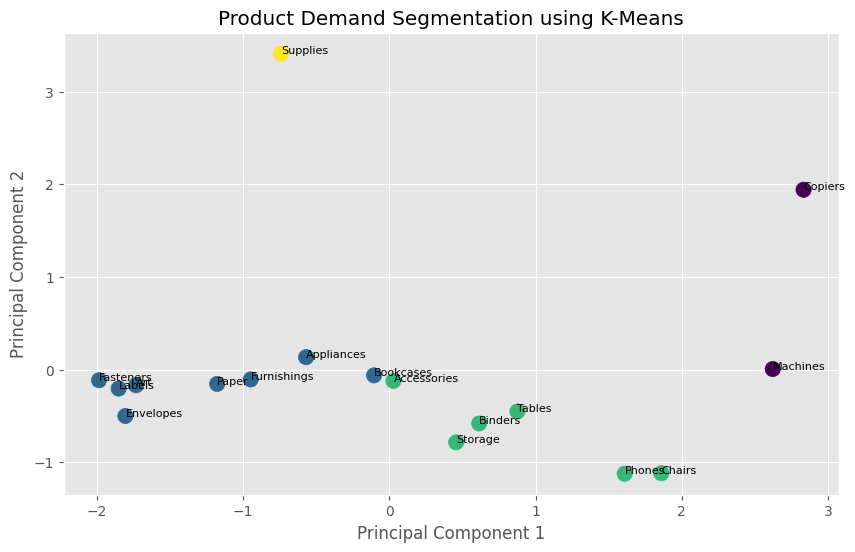

In [540]:
#PCA Plot
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

plt.scatter(
    cluster_data["PC1"],
    cluster_data["PC2"],
    c=cluster_data["Cluster"],
    cmap="viridis",
    s=120
)

for i in range(len(cluster_data)):
    plt.text(
        cluster_data["PC1"][i],
        cluster_data["PC2"][i],
        cluster_data["Sub-Category"][i],
        fontsize=8
    )

plt.title("Product Demand Segmentation using K-Means")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.grid(True)
plt.savefig(
    "product_demand_segmentation_kmeans.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

Observation :

The PCA scatter plot visualizes the product sub-categories in two dimensions while preserving most of the variation in the data. Products belonging to the same cluster are grouped closely together, indicating similar demand characteristics.

In [534]:
strategy = pd.DataFrame({
    "Demand Pattern (Cluster)": [
        "High Volume, Stable Demand",
        "Low Volume, Stable Demand",
        "High Value, High Volatility",
        "Growing Demand"
    ],

    "Recommended Stocking Strategy": [
        "Maintain high inventory levels and ensure continuous stock availability because these products generate consistent sales.",
        "Keep moderate inventory levels and replenish stock periodically to minimize storage costs while avoiding stockouts.",
        "Monitor demand closely and maintain safety stock, as these products have high value but fluctuating demand.",
        "Increase inventory gradually and monitor sales trends regularly to support rising customer demand and prevent future stock shortages."
    ]
})

strategy

,Demand Pattern (Cluster),Recommended Stocking Strategy
0,"High Volume, Stable Demand",Maintain high inventory levels and ensure cont...
1,"Low Volume, Stable Demand",Keep moderate inventory levels and replenish s...
2,"High Value, High Volatility",Monitor demand closely and maintain safety sto...
3,Growing Demand,Increase inventory gradually and monitor sales...


# Task 7: Streamlit Dashboard

A complete interactive Streamlit web application was developed to present the results of the Sales Forecasting and Demand Prediction System.

### Features Implemented

- Sales Overview Dashboard
  - Total Sales by Year
  - Monthly Sales Trend
  - Sales by Region and Category (Interactive Filters)

- Forecast Explorer
  - Category/Region Selection
  - Forecast Horizon (1–3 Months)
  - XGBoost Forecast
  - MAE and RMSE Display

- Anomaly Report
  - Isolation Forest Anomaly Visualization
  - Detected Anomaly Table

- Product Demand Segments
  - K-Means Cluster Visualization
  - Sub-Category Demand Segment Table

The complete implementation is available in the attached `app.py` file and has been deployed on Streamlit Community Cloud.

* # Task 8 – Executive Business Report (Notebook Summary)

Executive Summary :

This project analyzes historical retail sales data to forecast future demand, detect unusual sales patterns, and segment products based on demand behavior. The developed system helps improve inventory planning, reduce stock-related costs, and support better business decision-making.

Key Findings :

Technology generated the highest overall revenue, while the West region showed the strongest sales growth. Sales exhibited clear seasonal patterns, with higher demand during the final months of the year. Overall sales showed an increasing trend across the four-year period.

3-Month Sales Forecast :

The forecasting model predicts stable sales for the next three months, with forecasted values of 86,465.82, 86,506.77, and 84,327.28. These forecasts indicate consistent customer demand and support proactive inventory planning.

Top 3 Anomalies :

Major sales spikes were detected on 22-Mar-2015, 18-Nov-2018, and 02-Dec-2018. These unusual sales patterns are likely associated with promotional campaigns, festive seasons, or increased customer demand.

Product Demand Segmentation :

Products were grouped into four demand segments: High Volume Stable Demand, Low Volume Stable Demand, High Value High Volatility, and Growing Demand. These segments help businesses apply different inventory strategies based on product demand characteristics.

Business Recommendations :

* Maintain higher inventory for consistently high-demand products.
* Increase stock before seasonal peak periods to avoid stock shortages.
* Continuously monitor sales anomalies to improve demand planning and inventory management.

Risk / Limitation :

The forecasting system relies on historical sales data and may not fully capture unexpected external factors such as economic changes, supply chain disruptions, or future promotional events. Regular model updates are recommended to maintain forecasting accuracy.

Conclusion :

The developed sales forecasting system provides valuable support for inventory planning, demand forecasting, anomaly detection, and product segmentation. It enables data-driven decision-making and helps improve overall supply chain efficiency.